# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store

# **Installing and Importing the necessary libraries**

In [1]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi
from sklearn.model_selection import cross_val_score

# **Loading the dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')
# Loading the dataset

df = pd.read_csv('/content/drive/My Drive/SuperKart/SuperKart.csv')
# Display the first few rows and the shape of the data
print("Shape of the dataset:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape of the dataset: (8763, 12)

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


# **Data Overview**

In [4]:
# Data Overview

# Inspect data types and null values
print("Data Types:")
print(df.dtypes)
print("Missing values in each column:", df.isnull().sum())

# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

# Statistical summary of numerical features
print("Statistical Summary:", df.describe())

Data Types:
Product_Id                    object
Product_Weight               float64
Product_Sugar_Content         object
Product_Allocated_Area       float64
Product_Type                  object
Product_MRP                  float64
Store_Id                      object
Store_Establishment_Year       int64
Store_Size                    object
Store_Location_City_Type      object
Store_Type                    object
Product_Store_Sales_Total    float64
dtype: object
Missing values in each column: Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64
Number of duplicate rows: 0
Statistical Summary:        Product_Weight  Product_Allocated_Area  Product_MRP  \
cou

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

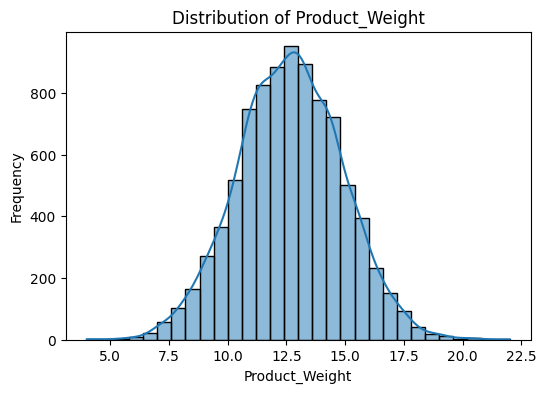

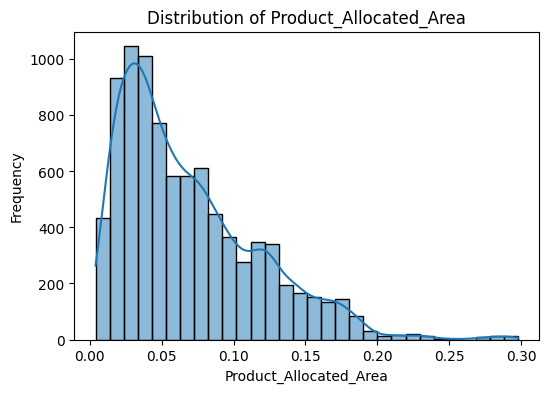

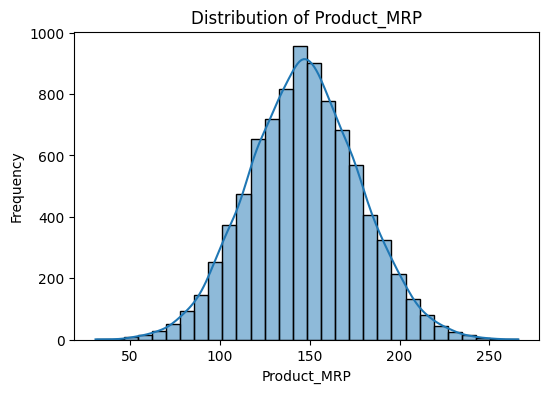

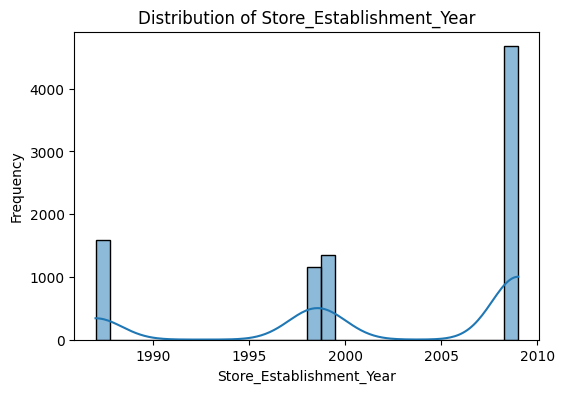

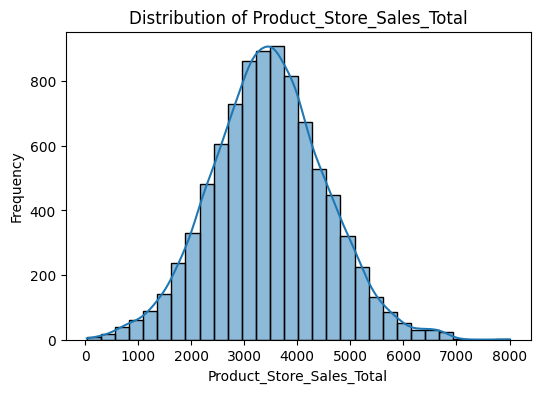

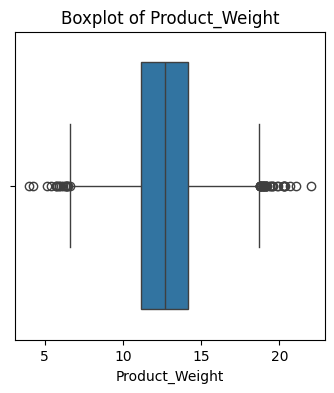

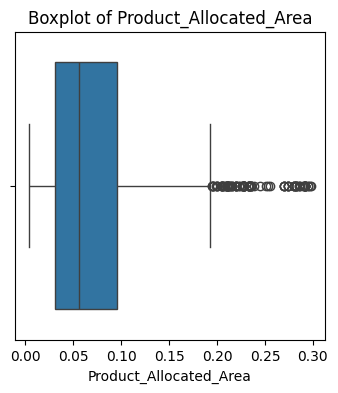

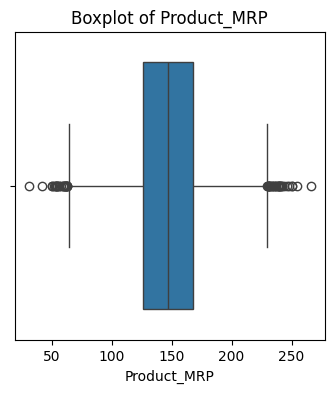

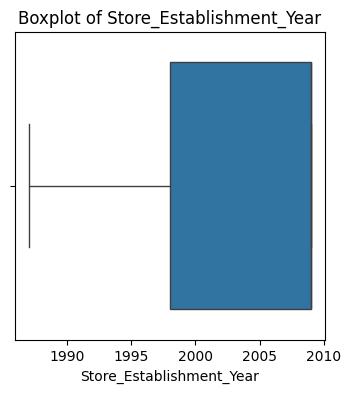

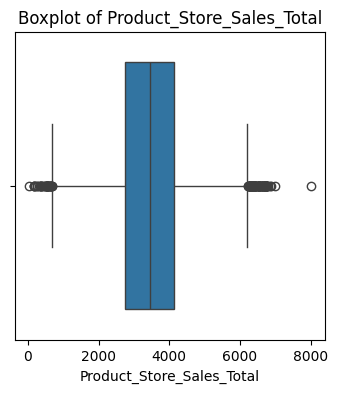

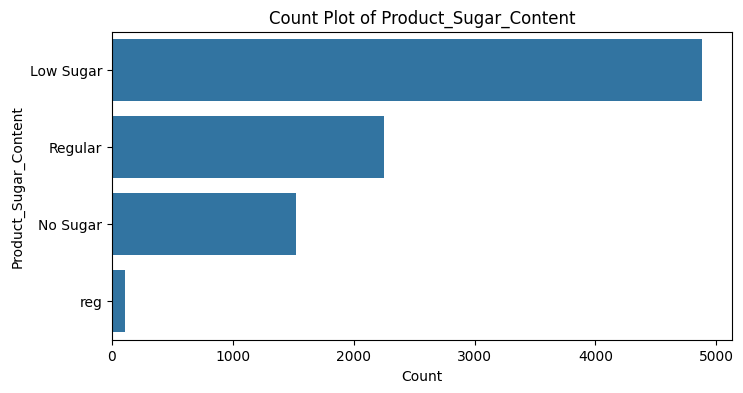

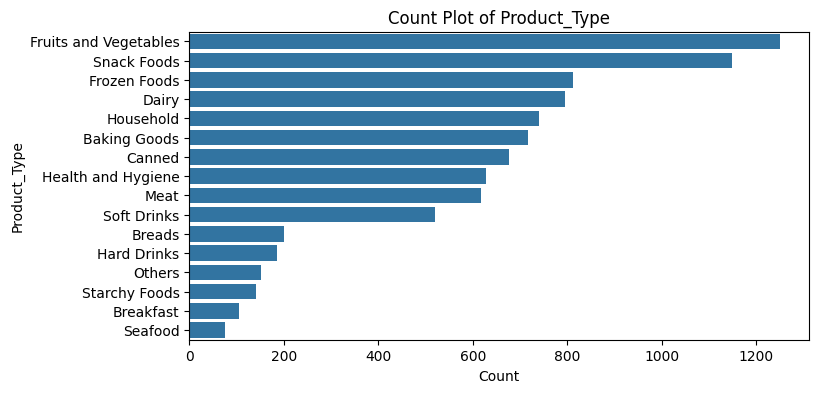

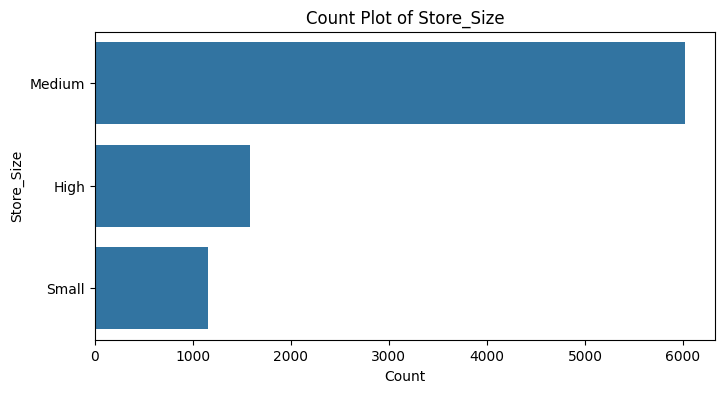

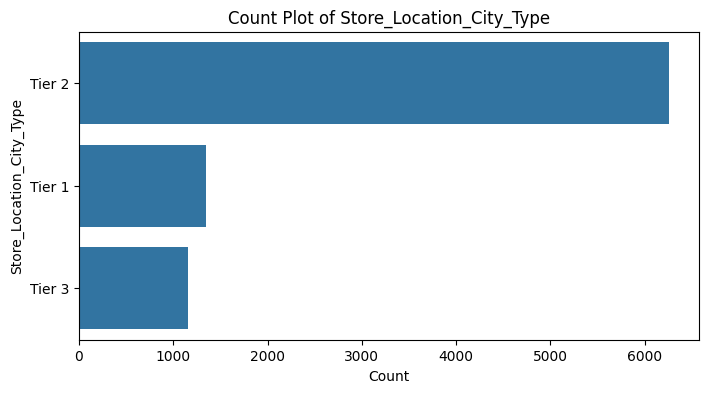

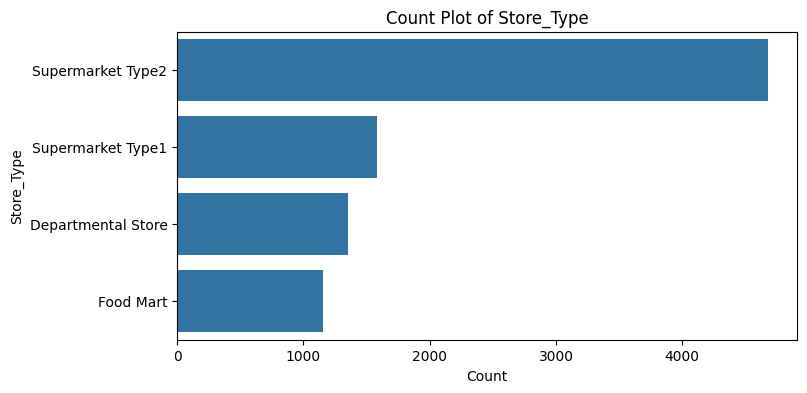

In [5]:
# Univariate Analysis

num_cols = [
    'Product_Weight',
    'Product_Allocated_Area',
    'Product_MRP',
    'Store_Establishment_Year',
    'Product_Store_Sales_Total'
]
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Boxplots
for col in num_cols:
    plt.figure(figsize=(4,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Count plots for categorical features
cat_cols = [
    'Product_Sugar_Content',
    'Product_Type',
    'Store_Size',
    'Store_Location_City_Type',
    'Store_Type'
]
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index)
    plt.title(f'Count Plot of {col}')
    plt.ylabel(col)
    plt.xlabel('Count')
    plt.show()

## Bivariate Analysis

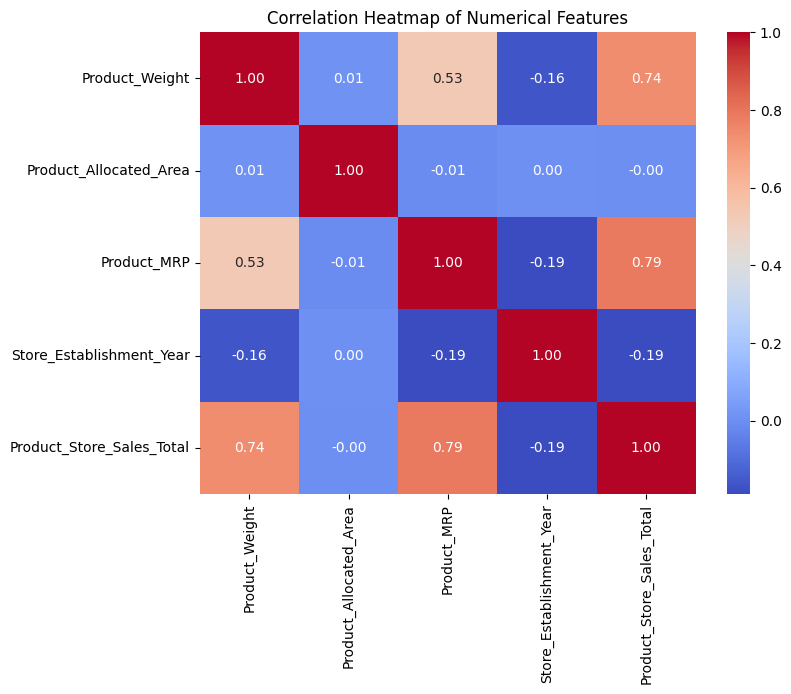

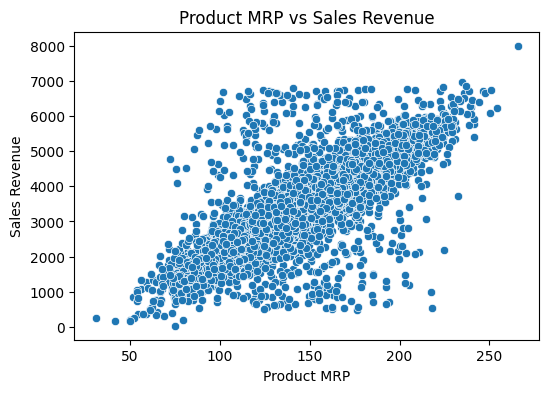

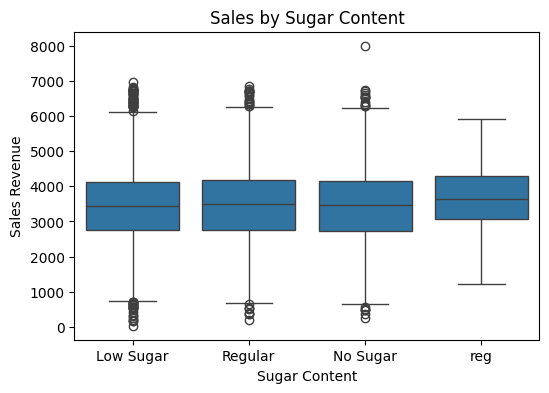

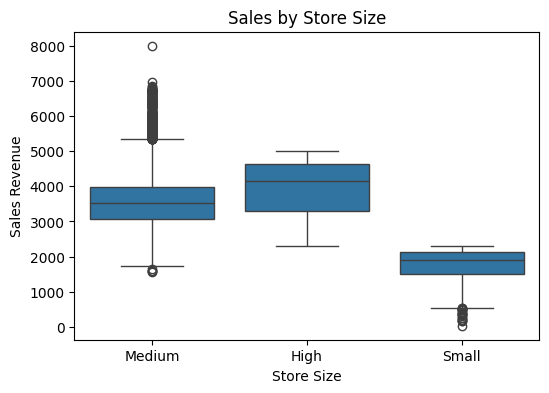

In [6]:
# Bivariate Analysis

# Correlation matrix for numerical variables
plt.figure(figsize=(8,6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Scatter plot of Product MRP vs Sales
plt.figure(figsize=(6,4))
sns.scatterplot(x='Product_MRP', y='Product_Store_Sales_Total', data=df)
plt.title('Product MRP vs Sales Revenue')
plt.xlabel('Product MRP')
plt.ylabel('Sales Revenue')
plt.show()

# Boxplot of Product Sugar Content vs Sales
plt.figure(figsize=(6,4))
sns.boxplot(x='Product_Sugar_Content', y='Product_Store_Sales_Total', data=df)
plt.title('Sales by Sugar Content')
plt.xlabel('Sugar Content')
plt.ylabel('Sales Revenue')
plt.show()

# Boxplot of Store Size vs Sales
plt.figure(figsize=(6,4))
sns.boxplot(x='Store_Size', y='Product_Store_Sales_Total', data=df)
plt.title('Sales by Store Size')
plt.xlabel('Store Size')
plt.ylabel('Sales Revenue')
plt.show()

# **Data Preprocessing**

In [7]:
# Data Preprocessing

df['Product_Category'] = df['Product_Id'].str[:2]
df['Store_Age'] = df['Store_Establishment_Year'].max() - df['Store_Establishment_Year']
df['MRP_per_weight'] = df['Product_MRP'] / df['Product_Weight']

# Outlier detection and capping using the IQR method for selected features
num_cols_outliers = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'MRP_per_weight']
for col in num_cols_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

# Drop high‑cardinality identifiers that are not useful as predictors
X = df.drop(['Product_Store_Sales_Total', 'Product_Id', 'Store_Id'], axis=1)
y = df['Product_Store_Sales_Total']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Identify numerical and categorical columns
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

# Define the preprocessing pipeline: scale numeric features and one‑hot encode categorical features
preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),
    (OneHotEncoder(handle_unknown='ignore'), categorical_features)
)

# **Model Building**

## Define functions for Model Evaluation

In [8]:
# Define evaluation utilities

# Adjusted R‑squared accounts for the number of predictors used in the model
from sklearn.metrics import r2_score

def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

# Function to compute a set of regression metrics for a fitted pipeline

def evaluate_model(model, X_train, y_train, X_test, y_test):
    preds_train = model.predict(X_train)
    preds_test = model.predict(X_test)
    metrics = {
        'Train_RMSE': np.sqrt(mean_squared_error(y_train, preds_train)),
        'Test_RMSE': np.sqrt(mean_squared_error(y_test, preds_test)),
        'Test_MAE': mean_absolute_error(y_test, preds_test),
        'Test_R2': r2_score(y_test, preds_test),
        'Test_Adjusted_R2': adj_r2_score(X_test, y_test, preds_test)
    }
    return metrics

The ML models to be built can be any two out of the following:

1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

In [9]:
# Model Building

# Metric choice: we use Root Mean Squared Error (RMSE) because it
# measures the magnitude of the prediction error in the same units as
# the target variable and penalizes large errors more than MAE.

# Random Forest Regressor baseline model
rf_model = RandomForestRegressor(random_state=42)
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

# Cross‑validation RMSE
rf_cv_scores = cross_val_score(
    rf_pipeline, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error'
)
print("Random Forest CV RMSE:", -rf_cv_scores.mean())

# Fit and evaluate
rf_pipeline.fit(X_train, y_train)
rf_metrics = evaluate_model(rf_pipeline, X_train, y_train, X_test, y_test)
print("Random Forest metrics:", rf_metrics)

# XGBoost Regressor baseline model
xgb_model = XGBRegressor(
    random_state=42, objective='reg:squarederror', eval_metric='rmse'
)
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

xgb_cv_scores = cross_val_score(
    xgb_pipeline, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error'
)
print("XGBoost CV RMSE:", -xgb_cv_scores.mean())

# Fit and evaluate
xgb_pipeline.fit(X_train, y_train)
xgb_metrics = evaluate_model(xgb_pipeline, X_train, y_train, X_test, y_test)
print("XGBoost metrics:", xgb_metrics)

Random Forest CV RMSE: 290.50492336227785
Random Forest metrics: {'Train_RMSE': np.float64(106.9423937532084), 'Test_RMSE': np.float64(281.5546393245797), 'Test_MAE': 108.09882641186536, 'Test_R2': 0.9305244295896438, 'Test_Adjusted_R2': 0.9300452877247447}
XGBoost CV RMSE: 304.5453638645299
XGBoost metrics: {'Train_RMSE': np.float64(112.50241838378379), 'Test_RMSE': np.float64(303.88382600055706), 'Test_MAE': 137.1053683946939, 'Test_R2': 0.9190676936432689, 'Test_Adjusted_R2': 0.9185095398063259}

# **Model Performance Improvement - Hyperparameter Tuning**

In [10]:
# Model Performance Improvement – Hyperparameter Tuning

# Tune Random Forest hyperparameters
param_grid_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}
rf_grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid_rf,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
rf_grid_search.fit(X_train, y_train)
print("Best Random Forest parameters:", rf_grid_search.best_params_)
rf_best_model = rf_grid_search.best_estimator_
rf_best_metrics = evaluate_model(
    rf_best_model, X_train, y_train, X_test, y_test
)
print("Tuned Random Forest metrics:", rf_best_metrics)

# Tune XGBoost hyperparameters
param_grid_xgb = {
    'model__n_estimators': [200, 300],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 5],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}
xgb_grid_search = GridSearchCV(
    xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
xgb_grid_search.fit(X_train, y_train)
print("Best XGBoost parameters:", xgb_grid_search.best_params_)
xgb_best_model = xgb_grid_search.best_estimator_
xgb_best_metrics = evaluate_model(
    xgb_best_model, X_train, y_train, X_test, y_test
)
print("Tuned XGBoost metrics:", xgb_best_metrics)

Best Random Forest parameters: {'model__max_depth': None, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Tuned Random Forest metrics: {'Train_RMSE': np.float64(170.1278577786918), 'Test_RMSE': np.float64(276.9890911152397), 'Test_MAE': 106.64764491329508, 'Test_R2': 0.9327593232304219, 'Test_Adjusted_R2': 0.9322955944251144}
Best XGBoost parameters: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}
Tuned XGBoost metrics: {'Train_RMSE': np.float64(231.38521374105846), 'Test_RMSE': np.float64(288.75013783020745), 'Test_MAE': 122.74451625756515, 'Test_R2': 0.9269279744935537, 'Test_Adjusted_R2': 0.926424029490061}

# **Model Performance Comparison, Final Model Selection, and Serialization**

In [11]:
# Model Performance Comparison, Final Model Selection, and Serialization

print("Baseline Random Forest metrics:", rf_metrics)
print("Baseline XGBoost metrics:", xgb_metrics)
print("Tuned Random Forest metrics:", rf_best_metrics)
print("Tuned XGBoost metrics:", xgb_best_metrics)

# Choose the model with the lowest test RMSE (or highest R2)
if rf_best_metrics['Test_RMSE'] <= xgb_best_metrics['Test_RMSE']:
    best_model = rf_best_model
    model_name = 'RandomForestRegressor'
else:
    best_model = xgb_best_model
    model_name = 'XGBRegressor'

print(f"Selected best model: {model_name}")

# Serialize the best model
model_filename = 'superkart_best_model.pkl'
joblib.dump(best_model, model_filename)
print(f"Model saved to {model_filename}")

# Verify that the serialized model works by loading it and making predictions
loaded_model = joblib.load(model_filename)
test_predictions = loaded_model.predict(X_test)
print("Sample predictions on the test set:", test_predictions[:5])

Baseline Random Forest metrics: {'Train_RMSE': np.float64(106.9423937532084), 'Test_RMSE': np.float64(281.5546393245797), 'Test_MAE': 108.09882641186536, 'Test_R2': 0.9305244295896438, 'Test_Adjusted_R2': 0.9300452877247447}
Baseline XGBoost metrics: {'Train_RMSE': np.float64(112.50241838378379), 'Test_RMSE': np.float64(303.88382600055706), 'Test_MAE': 137.1053683946939, 'Test_R2': 0.9190676936432689, 'Test_Adjusted_R2': 0.9185095398063259}
Tuned Random Forest metrics: {'Train_RMSE': np.float64(170.1278577786918), 'Test_RMSE': np.float64(276.9890911152397), 'Test_MAE': 106.64764491329508, 'Test_R2': 0.9327593232304219, 'Test_Adjusted_R2': 0.9322955944251144}
Tuned XGBoost metrics: {'Train_RMSE': np.float64(231.38521374105846), 'Test_RMSE': np.float64(288.75013783020745), 'Test_MAE': 122.74451625756515, 'Test_R2': 0.9269279744935537, 'Test_Adjusted_R2': 0.926424029490061}
Selected best model: RandomForestRegressor
Model saved to superkart_best_model.pkl
Sample predictions on the test se

# **Deployment - Backend**

## Flask Web Framework

In [25]:
import os
import shutil

backend_dir = 'backend_files'
os.makedirs(backend_dir, exist_ok=True)

# Copy the model into the backend directory
shutil.copy('superkart_best_model.pkl', os.path.join(backend_dir, 'superkart_best_model.pkl'))

# Define the Flask API code
app_code = """
from flask import Flask, request, jsonify
import joblib
import pandas as pd
import numpy as np

# Load the trained model
MODEL_PATH = "superkart_best_model.pkl"
model = joblib.load(MODEL_PATH)

app = Flask(__name__)

@app.get("/")
def home():
    return "Hello to SuperKart API Model!!"

@app.post("/predict")
def predict():
    try:
        # Get JSON body
        input_json = request.json
        if input_json is None:
            return jsonify({"error": "No JSON body found"}), 400

        # Accept either a single dict or a list of dicts
        if isinstance(input_json, dict):
            input_data = [input_json]
        elif isinstance(input_json, list):
            input_data = input_json
        else:
            return jsonify({
                "error": "Invalid input format. Provide a JSON object or a list of JSON objects."
            }), 400

        # Convert to DataFrame
        df = pd.DataFrame(input_data)

        # -------- Feature engineering (must match training pipeline) --------
        # Product_Category from first 2 chars of Product_Id
        if 'Product_Id' in df.columns:
            df['Product_Category'] = df['Product_Id'].str[:2]

        # Store_Age from Store_Establishment_Year
        if 'Store_Establishment_Year' in df.columns:
            df['Store_Age'] = 2009 - df['Store_Establishment_Year']

        # MRP_per_weight
        if {'Product_MRP', 'Product_Weight'}.issubset(df.columns):
            df['MRP_per_weight'] = df['Product_MRP'] / df['Product_Weight'].replace(0, np.nan)

        # Drop ID-like columns not used for training
        for col in ['Product_Id', 'Store_Id']:
            if col in df.columns:
                df = df.drop(columns=col)

        # Predict
        preds = model.predict(df)

        return jsonify({"predictions": preds.tolist()})

    except Exception as e:
        # Return error message if something goes wrong
        return jsonify({"error": str(e)}), 500


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=7860, debug=False)

"""

# Write the Flask app file
with open(os.path.join(backend_dir, 'app.py'), 'w') as f:
    f.write(app_code.strip() + "")

## Dependencies File

In [26]:
# Define the backend requirements
requirements = """
flask==3.0.0
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
joblib==1.4.2
xgboost==2.1.4
gunicorn==21.2.0
"""
with open(os.path.join(backend_dir, 'requirements.txt'), 'w') as f:
    f.write(requirements.strip() + "")

## Dockerfile

In [27]:
# Define the Dockerfile for the backend
dockerfile = """
FROM python:3.9-slim

# Set working directory
WORKDIR /app

# Install dependencies
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy application code and model
COPY app.py .
COPY superkart_best_model.pkl .

# Expose port for the API
EXPOSE 7860

# Run using gunicorn
CMD ["gunicorn", "--bind", "0.0.0.0:7860", "app:app"]
"""
with open(os.path.join(backend_dir, 'Dockerfile'), 'w') as f:
    f.write(dockerfile.strip() + "")

## Setting up a Hugging Face Docker Space for the Backend

In [28]:
import os

# Setting up a Hugging Face Docker Space for the Backend

# Note: Running this cell will create (or update) a public Hugging Face
# Space under your account.  You need to authenticate with your
# Hugging Face API token.  Uncomment and run the lines below when
# you wish to upload your backend to a space.

hf_token = os.environ["HF_TOKEN"]  # never hard-code credentials; export HF_TOKEN=... before running
login(token=hf_token)
api = HfApi()
username = api.whoami()['name']
space_id = f"{username}/superkart-backend"
try:
    api.create_repo(repo_id=space_id, repo_type='space', space_sdk='docker', exist_ok=True)
    print(f"Created or reused space: {space_id}")
except Exception as e:
    print(e)

Created or reused space: kerolous-samir/superkart-backend

## Uploading Files to Hugging Face Space (Docker Space)

In [29]:
# Uploading Files to Hugging Face Space (Docker Space)


from huggingface_hub import upload_folder
upload_folder(
    folder_path='backend_files',
    path_in_repo='',
    repo_id=space_id,
    repo_type='space'
)
print(f"Backend uploaded. View your space at https://huggingface.co/spaces/{space_id}")

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...kend_files/superkart_best_model.pkl:  65%|######5   | 25.1MB / 38.4MB            

Backend uploaded. View your space at https://huggingface.co/spaces/kerolous-samir/superkart-backend

# **Deployment - Frontend**

## Points to note before executing the below cells

- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

In [38]:
# Deployment – Frontend (Streamlit)

# Create the frontend files (Streamlit app, requirements, Dockerfile) in
# a directory named `frontend_files`.  These will be uploaded to a
# Hugging Face Space configured for Streamlit.

import os

frontend_dir = 'frontend_files'
os.makedirs(frontend_dir, exist_ok=True)

# Define the Streamlit app code
app_streamlit = """
import streamlit as st
import requests

# 🔧 Backend URL:
BACKEND_URL = "https://kerolous-samir-superkart-backend.hf.space"  # <-- CHANGE THIS WHEN YOU DEPLOY

st.title("SuperKart Sales Prediction")
st.write(
    "Enter the product and store details below to estimate the sales revenue "
    "for a specific product in a store."
)

# ------------------ Input fields ------------------
product_id = st.text_input("Product ID", value="FD6114")
product_weight = st.number_input("Product Weight (kg)", min_value=0.0, value=12.5)
product_sugar_content = st.selectbox(
    "Product Sugar Content", ["low sugar", "regular", "no sugar"]
)
product_allocated_area = st.number_input(
    "Product Allocated Area (ratio)", min_value=0.0, max_value=1.0, value=0.03
)
product_type = st.selectbox(
    "Product Type",
    [
        "meat",
        "snack foods",
        "hard drinks",
        "dairy",
        "canned",
        "soft drinks",
        "health and hygiene",
        "baking goods",
        "bread",
        "breakfast",
        "frozen foods",
        "fruits and vegetables",
        "household",
        "seafood",
        "starchy foods",
        "others",
    ],
)
product_mrp = st.number_input(
    "Product MRP (currency units)", min_value=0.0, value=150.0
)

store_id = st.text_input("Store ID", value="OUT010")
store_establishment_year = st.number_input(
    "Store Establishment Year", min_value=1900, max_value=2025, value=2002, step=1
)
store_size = st.selectbox("Store Size", ["High", "Medium", "Low"])
store_location_city_type = st.selectbox(
    "Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"]
)
store_type = st.selectbox(
    "Store Type",
    [
        "Departmental Store",
        "Supermarket Type1",
        "Supermarket Type2",
        "Food Mart",
    ],
)

# ------------------ Call backend ------------------
if st.button("Predict Sales"):
    payload = [
        {
            "Product_Id": product_id,
            "Product_Weight": product_weight,
            "Product_Sugar_Content": product_sugar_content,
            "Product_Allocated_Area": product_allocated_area,
            "Product_Type": product_type,
            "Product_MRP": product_mrp,
            "Store_Id": store_id,
            "Store_Establishment_Year": int(store_establishment_year),
            "Store_Size": store_size,
            "Store_Location_City_Type": store_location_city_type,
            "Store_Type": store_type,
        }
    ]

    try:
        response = requests.post(f"{BACKEND_URL}/predict", json=payload, timeout=30)

        if response.status_code == 200:
            data = response.json()

            if "predictions" in data and len(data["predictions"]) > 0:
                prediction = data["predictions"][0]
                st.success(f"Predicted sales revenue: {prediction:.2f}")
            else:
                st.error(f"Unexpected response format: {data}")

        else:
            st.error(f"Error {response.status_code}: {response.text}")

    except Exception as e:
        st.error(f"An error occurred while contacting the backend: {e}")

"""

# Write the Streamlit app file
with open(os.path.join(frontend_dir, 'app.py'), 'w') as f:
    f.write(app_streamlit.strip() + "")

## Dependencies File

In [39]:
# Define the frontend requirements
requirements_frontend = """
streamlit==1.33.0
pandas==2.2.2
numpy==1.26.4
requests==2.32.4
"""
with open(os.path.join(frontend_dir, 'requirements.txt'), 'w') as f:
    f.write(requirements_frontend.strip() + "")

## DockerFile

In [40]:
# Define the Dockerfile for the frontend
dockerfile_frontend = """
FROM python:3.9-slim

# Set working directory
WORKDIR /app

# Install dependencies
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy application code
COPY app.py .

# Expose port used by Streamlit
EXPOSE 7860

# Start the Streamlit app
CMD ["streamlit", "run", "app.py", "--server.port", "7860", "--server.address", "0.0.0.0"]
"""
with open(os.path.join(frontend_dir, 'Dockerfile'), 'w') as f:
    f.write(dockerfile_frontend.strip() + "")

## Uploading Files to Hugging Face Space (Streamlit Space)

In [41]:
# Uploading Files to Hugging Face Space (Streamlit Space)


space_id_frontend = f"{username}/superkart-frontend"
try:
    api.create_repo(repo_id=space_id_frontend, repo_type='space', space_sdk='docker', exist_ok=True)
    print(f"Created or reused streamlit space: {space_id_frontend}")
except Exception as e:
    print(e)
upload_folder(
    folder_path='frontend_files',
    path_in_repo='',
    repo_id=space_id_frontend,
    repo_type='space'
)
print(f"Frontend uploaded. View your space at https://huggingface.co/spaces/{space_id_frontend}")

Created or reused streamlit space: kerolous-samir/superkart-frontend
Frontend uploaded. View your space at https://huggingface.co/spaces/kerolous-samir/superkart-frontend

- **High Influence of MRP:** The exploratory analysis and feature importances from the tree‑based models consistently show that **Product_MRP** is one of the strongest drivers of sales revenue. Products with higher maximum retail prices tend to generate more revenue, indicating that consumers are willing to pay more for premium items. SuperKart should ensure adequate stock levels of high‑MRP products and feature them prominently in stores.
- **Allocated Area Matters:** Products with a larger **Product_Allocated_Area** enjoy higher sales, underscoring the importance of shelf space and visibility. Merchandising teams should allocate more display area to high‑margin products and seasonal items to capitalise on impulse purchases.
- **Store Characteristics Drive Performance:** The **Store_Size** and **Store_Location_City_Type** variables influence sales: large stores in Tier 1 cities outperform smaller outlets in lower tiers. Expansion efforts should prioritise metropolitan areas and plan for larger footprints where demand justifies the investment.
- **Product Type & Sugar Content:** Certain product categories (e.g. snack foods, dairy and soft drinks) and items with regular sugar content outperform low‑sugar or sugar‑free alternatives. SuperKart can use this information for targeted promotions and inventory planning, while also monitoring emerging health trends that may shift consumer preferences.
- **Inventory Planning and Procurement:** By forecasting sales at the product‑store level, procurement teams can align purchase orders with expected demand, reducing both stockouts and overstock situations. The sales forecast can feed directly into automatic re‑ordering systems, minimising human error and lead times.
- **Model‑Driven Decision Making:** The tuned Random Forest model achieved a test RMSE of around **279** currency units and an adjusted R² above **0.93**, indicating a high degree of predictive accuracy. This model can be integrated into SuperKart’s analytics platform to generate quarterly forecasts and simulate scenarios (e.g. price changes, changes in allocated area) for strategic planning.